# Evaluation of two-branch models

In [15]:
#check the evironement path
import sys
sys.executable

'/usr/bin/python'

In [5]:
import tensorflow as tf
print(tf.__version__)
import keras
print(keras.__version__)

1.15.2
2.2.4


Using TensorFlow backend.


In [6]:
from keras.models import Model
from keras import backend as K

# Loading Data: Testing images + labels

In [7]:
#import arcpy
from glob import glob
import numpy as np
from numpy import ndarray
import rasterio

In [8]:
path="/linux_data/test_S1TS_S2/*/"
data = glob(path)

data_tiles_list = []
label_tiles_list = []


data_tiles_list.append(glob(data[1]+ "/*.tif"))
label_tiles_list.append(glob(data[0]+ "/*.tif"))


data_tiles_list = [y for x in data_tiles_list for y in x]
label_tiles_list = [y for x in label_tiles_list for y in x]
print(len(data_tiles_list))
print(len(label_tiles_list))

4518
4518


### Testing images

#### First stream: Sentinel-1

#### Time series: 12 months

In [9]:
nb_tiles=10
#nb_tiles=int(len(data_tiles_list)*0.8)

tr_images_s1 = []

for i in range(nb_tiles):
    print(str(i) + "/" + str(nb_tiles))
    
    
    data_in = rasterio.open(data_tiles_list[i]) #opens the .tif/Raster in an array    
    t = np.concatenate((np.expand_dims(data_in.read(1), axis=2), np.expand_dims(data_in.read(2), axis=2)), axis=2) #expands the array by 1 dimension
    t1 =np.expand_dims(t, axis=0)

    for j in range(3,25,2): #expands the array by j dimensions and adds them together (concatenate)
        t = np.concatenate((np.expand_dims(data_in.read(j), axis=2), np.expand_dims(data_in.read(j+1), axis=2)), axis=2)
        t1 = np.concatenate((t1, np.expand_dims(t, axis=0)), axis=0) 
    tr_images_s1.append(t1)
    

testing_images_s1 = np.asarray(tr_images_s1) # converts list training_images into an array
del tr_images_s1

print(testing_images_s1.shape)

0/10
1/10
2/10
3/10
4/10
5/10
6/10
7/10
8/10
9/10
(10, 12, 256, 256, 2)


#### Time series: 7 months

In [10]:
tr_images_s1 = []

for i in range(nb_tiles):
    print(str(i) + "/" + str(nb_tiles))
    
    
    data_in = rasterio.open(data_tiles_list[i]) #opens the .tif/Raster in an array    
    t = np.concatenate((np.expand_dims(data_in.read(11), axis=2), np.expand_dims(data_in.read(12), axis=2)), axis=2) #expands the array by 1 dimension
    t1 =np.expand_dims(t, axis=0)

    for j in range(13,25,2): #expands the array by j dimensions and adds them together (concatenate)
        t = np.concatenate((np.expand_dims(data_in.read(j), axis=2), np.expand_dims(data_in.read(j+1), axis=2)), axis=2)
        t1 = np.concatenate((t1, np.expand_dims(t, axis=0)), axis=0) 
    tr_images_s1.append(t1)
    

testing_images_s1 = np.asarray(tr_images_s1) # converts list training_images into an array
del tr_images_s1

print(testing_images_s1.shape)

0/10
1/10
2/10
3/10
4/10
5/10
6/10
7/10
8/10
9/10
(10, 7, 256, 256, 2)


#### Second stream: Sentinel-2

In [11]:
tr_images_s2 = []


for i in range(nb_tiles):
    print(str(i) + "/" + str(nb_tiles))
    
    
    data_in = rasterio.open(data_tiles_list[i]) #opens the .tif/Raster in an array
    
    t = np.expand_dims(data_in.read(25), axis=2) #expands the array by 1 dimension

    for j in range(26,35): #expands the array by j dimensions and adds them together (concatenate)
        t = np.concatenate((t, np.expand_dims(data_in.read(j), axis=2)), axis=2)
        
    tr_images_s2.append(t)
    

testing_images_s2 = np.asarray(tr_images_s2) # converts list training_images into an array
del tr_images_s2

print(testing_images_s2.shape)

0/10
1/10
2/10
3/10
4/10
5/10
6/10
7/10
8/10
9/10
(10, 256, 256, 10)


### Labels

In [12]:
# Labels for training
from keras.utils import to_categorical

tr_labels=[]
for i in range(nb_tiles):
    print(str(i) + "/" + str(nb_tiles))
    data_in = rasterio.open(label_tiles_list[i]) #opens the .tif/Raster in an array    
    tr_labels.append(data_in.read(1))
        
testing_labels = np.asarray(tr_labels) # converts list training_images into an array
del tr_labels

print(testing_labels.shape)

0/10
1/10
2/10
3/10
4/10
5/10
6/10
7/10
8/10
9/10
(10, 256, 256)


### Settings of data set parameters

In [14]:
#nb_labels = testing_labels.shape[3]
#print(nb_labels)

timestamps = testing_images_s1.shape[1]
print(timestamps)

# The dimensions of the input images
nb_rows = testing_images_s2.shape[1]
print(nb_rows)
nb_cols = testing_images_s2.shape[2]
print(nb_cols)
channels1= testing_images_s1.shape[4]
print(channels1)
channels2= testing_images_s2.shape[3]
print(channels2)

if K.image_data_format() == 'channels_first':
    channel_axis = 1
    input_shape1=(timestamps,channels1,nb_rows,nb_cols)    
    input_shape2 = (channels2,nb_rows, nb_cols)
    
if K.image_data_format() == 'channels_last':
    channel_axis = 3
    input_shape1=(timestamps,nb_rows,nb_cols, channels1)
    input_shape2= (nb_rows,nb_cols,channels2)

print(input_shape1)
print(input_shape2)

7
256
256
2
10
(7, 256, 256, 2)
(256, 256, 10)


### Loading model

In [13]:
from keras.models import load_model
from keras.metrics import mean_squared_error

#Models to test:
#two_branchesM2_Amazon_12TS2-10_18074_CEWL_concat_new.h5
#two_branchesM2_Amazon_12-10_18074_CEWL_concat_new.h5
#two_branchesM2_Amazon_7TS2-10_18074_CEWL_concat_new.h5
#two_branchesUnet_Amazon_12-10_18074_CEWL_concat_new.h5

model_path="two_branchesUnet_Amazon_12-10_18074_CEWL_concat_new.h5"
model = load_model(model_path, custom_objects={'mean_iou': mean_squared_error,'tf':tf,'nb_rows':nb_rows , 'nb_cols': nb_cols})















Instructions for updating:
Please use `rate` instead of `keep_prob`. Rate should be set to `rate = 1 - keep_prob`.


Instructions for updating:
Use tf.where in 2.0, which has the same broadcast rule as np.where




### Model Evaluation

In [24]:
#Evaluation
lb = np.expand_dims(testing_labels, axis=3)
lb=to_categorical(lb)
evaluation = model.evaluate([testing_images_s1,testing_images_s2],[lb,lb,lb], verbose=1, batch_size=30)

10/10 [==============================] - 0s 32ms/step


In [15]:
model.metrics_names

['loss', 'mean_squared_error', 'acc']

In [16]:
print("%s: %.3f" % (model.metrics_names[1], evaluation[1]))
print("%s: %.3f" % (model.metrics_names[2], evaluation[2]))

mean_squared_error: 0.065
acc: 0.254


In [17]:
#Calculate predictions

p1,p2,p3 = model.predict([testing_images_s1,testing_images_s2], verbose=1, batch_size=30)
results=p3.argmax(axis=-1)

10/10 [==============================] - 4s 369ms/step


In [18]:
#The existing classes in ground-truth as well as prediction 
#>> useful for the Confusion matrix visialization

ts=set(testing_labels.flatten())
rs=set(results.flatten())
us=ts.union(rs)
print(us)
cls=np.array(us)

{1, 2, 6, 7, 8, 10, 14, 17}


### Visualisation Predictions

In [20]:
#!pip install skimage

#from skimage import io
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure

# Display prediction image
#M2
#colors of classes
### with skimage
'''palette = np.array([
[255, 255, 0]
, [39, 78, 19]
,[50, 205, 50]
,[104, 117, 55]
,[147, 81, 50]
,[69, 194, 165]
,[184, 175, 79]
,[255, 0, 0],
[255, 217, 102],
 [233, 116, 237]
, [213, 166, 189]
,[194, 123, 160]
,[221, 126, 107]
, [175, 42, 42]
, [255, 153, 255]
,[138, 43, 226]
,[25, 0, 0]
,[0, 0, 255]], dtype=np.uint8)
'''

'palette = np.array([\n[255, 255, 0]\n, [39, 78, 19]\n,[50, 205, 50]\n,[104, 117, 55]\n,[147, 81, 50]\n,[69, 194, 165]\n,[184, 175, 79]\n,[255, 0, 0],\n[255, 217, 102],\n [233, 116, 237]\n, [213, 166, 189]\n,[194, 123, 160]\n,[221, 126, 107]\n, [175, 42, 42]\n, [255, 153, 255]\n,[138, 43, 226]\n,[25, 0, 0]\n,[0, 0, 255]], dtype=np.uint8)\n'

In [ ]:
### with skimage
figure()
io.imshow(palette[results[5]])

([], <a list of 0 Text yticklabel objects>)

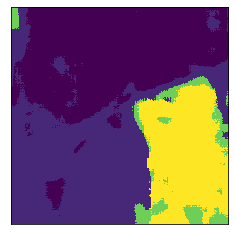

In [21]:
figure()
plt.imshow(results[5])
plt.xticks([])
plt.yticks([])

([], <a list of 0 Text yticklabel objects>)

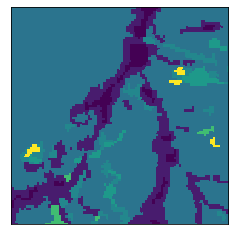

In [25]:
figure()
plt.imshow(testing_labels[5])
plt.xticks([])
plt.yticks([])

### Post Processing

#### CRF

In [26]:
#!pip install pydensecrf
import matplotlib.pyplot as plt
import pydensecrf.densecrf as dcrf
import pydensecrf.utils as utils
from pydensecrf.utils import unary_from_softmax, create_pairwise_bilateral

In [ ]:
#The existing classes in ground truth as well as prediction
'''ts=set(tr.flatten())
rs_Nor=set(results_Nor.flatten())
us_Nor=ts.union(rs_Nor)
print(us_Nor)
cls_Nor=np.array(us_Nor)'''

In [31]:
MAX_ITER = 10

POS_W = 3
POS_XY_STD = 1
Bi_W = 4
Bi_XY_STD = 67
Bi_RGB_STD = 3
crf_out=[]

for i in range(len(pred)):
    print(str(i) + "/" + str(len(pred)))
    test=np.transpose(pred[i,:,:,:],[2,0,1])
    c = test.shape[0]
    h = test.shape[1]
    w = test.shape[2]

    #is the output of DL model: probability of pixels
    U = utils.unary_from_softmax(test)
    U = np.ascontiguousarray(U)

    #The groung truth image
    img = np.ascontiguousarray(np.expand_dims(testing_labels[i], axis=3))

    d = dcrf.DenseCRF2D(w, h, c)
    d.setUnaryEnergy(U)
    d.addPairwiseGaussian(sxy=POS_XY_STD, compat=POS_W,normalization=dcrf.NORMALIZE_SYMMETRIC,kernel=dcrf.DIAG_KERNEL)
    #inference with unary potential: does not take account of the neighbourhood
    Q_unary = d.inference(MAX_ITER)

    pairwise_energy = create_pairwise_bilateral(sdims=(10,10), schan=(0.01,), img=img, chdim=2)
    d.addPairwiseEnergy(pairwise_energy, compat=Bi_W)

    #inference with bilateral potential
    Q = d.inference(MAX_ITER)
    #Q = np.array(Q).reshape((c, h, w))

    #Q_unary
    f_pred_un=np.array(Q_unary )
    new_un = np.array(f_pred_un).reshape((c, h, w))
    new_un=np.transpose(new_un,[1,2,0])
    #figure()
    #imgplot = plt.imshow(np.argmax(new_un,axis=2))

    #bilateral potential
    f_pred=np.array(Q)
    new = np.array(f_pred).reshape((c, h, w))
    new=np.transpose(new,[1,2,0])
    crf_out.append(new)
    #figure()
    #imgplot = plt.imshow(np.argmax(new,axis=2))

0/10


/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:22: DeprecationWarning: Both axis > a.ndim and axis < -a.ndim - 1 are deprecated and will raise an AxisError in the future.


1/10
2/10
3/10
4/10
5/10
6/10
7/10
8/10
9/10


In [32]:
crf=np.array(crf_out)
crf=np.argmax(crf,axis=3)
crf.shape

(10, 256, 256)

#### CRF Results visualization

<Figure size 432x288 with 0 Axes>

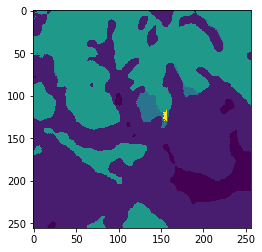

<Figure size 432x288 with 0 Axes>

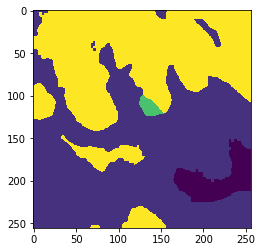

<Figure size 432x288 with 0 Axes>

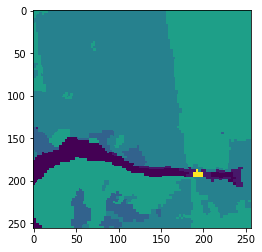

In [36]:
#m, n = 4, 6
#Unet
###Before
figure()
indices = results[0]
figure()
plt.imshow(indices)
#print(indices)
#io.imshow(palette[indices])

#after
figure()
indices = crf[0]
figure()
plt.imshow(indices)
#print(indices)
#io.imshow(palette[indices])

#labels
figure()
indices = testing_labels[0]
figure()
plt.imshow(indices)
#print(indices)
#io.imshow(palette[indices])

### Evaluation metrics

In [37]:
from sklearn.metrics import jaccard_score #Iou
from sklearn.metrics import f1_score #Dice_coeff
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

In [38]:
#labels={0:"Non Observed",  1: "Forest Formation" ,2: "Savanna Formation",3: "Mangrove" ,4: "Forest Plantation" ,5: "Wetland",6: "Grassland Formation",7: "Other non Forest Natural Formation" ,8: "Pasture" ,9: "Agriculture",10: "Annual and Perennial Crop",11: "Semi-perennial Crop",12: "Beach and Dune",13: "Urban Infrastructure",14: "Other Non-Vegetated Area",15: "Mining" ,16: "Salt Flat",17: "River, Lake and Ocean" }
#13: 1, 2, 4, 5, 6, 7, 8, 10, 11, 13, 14, 15, 17
target_names = ["Forest Formation" ,"Savanna Formation","Forest Plantation" ,"Wetland","Grassland Formation","Other non Forest Natural Formation" ,"Pasture" ,"Annual and Perennial Crop","Semi-perennial Crop","Urban Infrastructure","Other Non-Vegetated Area","Mining" ,"River, Lake and Ocean"]


In [40]:
report=classification_report(testing_labels.flatten(), results.flatten(),target_names=target_names)
print(report)

              precision    recall  f1-score   support

           1       0.14      0.21      0.17     71929
           2       0.35      0.38      0.37    259404
           6       0.06      0.01      0.01    121964
           7       0.10      0.01      0.02     27126
           8       0.31      0.36      0.34    138755
          10       0.00      0.00      0.00     31685
          14       0.00      0.00      0.00      2183
          17       0.00      0.00      0.00      2314

    accuracy                           0.25    655360
   macro avg       0.12      0.12      0.11    655360
weighted avg       0.24      0.25      0.24    655360



In [41]:
#normalized global acc
acc_gl_Nor=accuracy_score(testing_labels.flatten(), results.flatten())

In [43]:
#IOU for each class
IOU_each_cl_Nor=jaccard_score(testing_labels.flatten(), results.flatten(), average=None)
#Macro IOU for all classes
IOU_gl_Nor=jaccard_score(testing_labels.flatten(), results.flatten(), average='macro')

In [44]:
#F1 for each class
f1_each_cl_Nor=f1_score(testing_labels.flatten(), results.flatten(), average=None)
#Macro F1 for all classes
f1_gl_Nor=f1_score(testing_labels.flatten(), results.flatten(), average='macro')

In [45]:
print("%s: %.3f" % ("global accuracy", acc_gl_Nor))
print(" IOU_each_cl:",IOU_each_cl_Nor)
print("%s: %.3f" % ("Macro IOU", IOU_gl_Nor))
print("f1_each_cl", f1_each_cl_Nor)
print("%s: %.3f" % ("Macro f1", f1_gl_Nor))

global accuracy: 0.254
 IOU_each_cl: [0.09277939 0.22414358 0.00632879 0.00890047 0.20190498 0.00171869
 0.         0.        ]
Macro IOU: 0.067
f1_each_cl [0.16980443 0.36620472 0.01257797 0.0176439  0.33597495 0.00343149
 0.         0.        ]
Macro f1: 0.113


In [46]:
#########################Crf eval
report_crf=classification_report(testing_labels.flatten(), crf.flatten(),target_names=target_names)
print(report_crf)

              precision    recall  f1-score   support

           1       0.15      0.21      0.18     71929
           2       0.36      0.43      0.39    259404
           6       0.02      0.00      0.00    121964
           7       0.05      0.00      0.00     27126
           8       0.33      0.37      0.35    138755
          10       0.00      0.00      0.00     31685
          14       0.00      0.00      0.00      2183
          17       0.00      0.00      0.00      2314

    accuracy                           0.27    655360
   macro avg       0.11      0.13      0.11    655360
weighted avg       0.24      0.27      0.25    655360



In [47]:
##########Confusion Matrix
#>>>>>>using windows
#!pip install mlxtend
# from mlxtend.evaluate import confusion_matrix
# from mlxtend.plotting import plot_confusion_matrix

from sklearn.metrics import confusion_matrix
import matplotlib
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [48]:
'''cmTest=confusion_matrix(y_target=tr.flatten(), 
                      y_predicted=results.flatten(), 
                      binary=False)'''

cmTest=confusion_matrix(testing_labels.flatten(), 
                      results.flatten())

In [49]:
cmTest.shape

(8, 8)

In [50]:
######Confusion matrix Display
def heatmap(data, row_labels, col_labels, ax=None,
            cbar_kw={}, cbarlabel="", **kwargs):
    """
    Create a heatmap from a numpy array and two lists of labels.

    Parameters
    ----------
    data
        A 2D numpy array of shape (N, M).
    row_labels
        A list or array of length N with the labels for the rows.
    col_labels
        A list or array of length M with the labels for the columns.
    ax
        A `matplotlib.axes.Axes` instance to which the heatmap is plotted.  If
        not provided, use current axes or create a new one.  Optional.
    cbar_kw
        A dictionary with arguments to `matplotlib.Figure.colorbar`.  Optional.
    cbarlabel
        The label for the colorbar.  Optional.
    **kwargs
        All other arguments are forwarded to `imshow`.
    """

    if not ax:
        ax = plt.gca()

    #normalize the confusion matrix 
    col=data.sum(axis=1)[:, np.newaxis] #col of the sum of every row
    data = np.around(data.astype('float') / col, decimals=3)
    
    # Plot the heatmap
    im = ax.imshow(data,cmap=plt.cm.Blues, **kwargs)

    # Create colorbar
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.1)
    cbar = ax.figure.colorbar(im, cax=cax, **cbar_kw)
    cbar.ax.set_ylabel(cbarlabel, rotation=-90, va="bottom")

    # We want to show all ticks...
    ax.set_xticks(np.arange(len(col_labels)))
    ax.set_yticks(np.arange(len(row_labels)))
    # ... and label them with the respective list entries.
    ax.set_xticklabels(col_labels)
    ax.set_yticklabels(row_labels)
    

    # Let the horizontal axes labeling appear on top.
    ax.tick_params(top=True, bottom=False,
                   labeltop=True, labelbottom=False)

    # Rotate the tick labels and set their alignment.
    plt.setp(ax.get_xticklabels(), rotation=-30, ha="right",
             rotation_mode="anchor")

    # Turn spines off and create white grid.
    for edge, spine in ax.spines.items():
        spine.set_visible(False)

    ax.set_xticks(np.arange(len(col_labels)+1)-.5, minor=True)
    ax.set_yticks(np.arange(len(row_labels)+1)-.5, minor=True)
    ax.grid(which="minor", color="w", linestyle='-', linewidth=3)
    ax.tick_params(which="minor", bottom=False, left=False)
    ax.set_ylabel('True label', rotation=90, ha='left', va='center')
    ax.set_xlabel('Predicted label', rotation=0, ha='center', va='bottom')

    return im, cbar


def annotate_heatmap(im, data=None, valfmt="{x:.2f}",
                     textcolors=["black", "white"],
                     threshold=None, **textkw):
    """
    A function to annotate a heatmap.

    Parameters
    ----------
    im
        The AxesImage to be labeled.
    data
        Data used to annotate.  If None, the image's data is used.  Optional.
    valfmt
        The format of the annotations inside the heatmap.  This should either
        use the string format method, e.g. "$ {x:.2f}", or be a
        `matplotlib.ticker.Formatter`.  Optional.
    textcolors
        A list or array of two color specifications.  The first is used for
        values below a threshold, the second for those above.  Optional.
    threshold
        Value in data units according to which the colors from textcolors are
        applied.  If None (the default) uses the middle of the colormap as
        separation.  Optional.
    **kwargs
        All other arguments are forwarded to each call to `text` used to create
        the text labels.
    """

    if not isinstance(data, (list, np.ndarray)):
        data = im.get_array()

    # Normalize the threshold to the images color range.
    if threshold is not None:
        threshold = im.norm(threshold)
    else:
        threshold = im.norm(data.max())/2.

    # Set default alignment to center, but allow it to be
    # overwritten by textkw.
    kw = dict(horizontalalignment="center",
              verticalalignment="center")
    kw.update(textkw)

    # Get the formatter in case a string is supplied
    if isinstance(valfmt, str):
        valfmt = matplotlib.ticker.StrMethodFormatter(valfmt)

    # Loop over the data and create a `Text` for each "pixel".
    # Change the text's color depending on the data.
    texts = []
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            kw.update(color=textcolors[int(im.norm(data[i, j]) > threshold)])
            text = im.axes.text(j, i, valfmt(data[i, j], None), **kw)
            texts.append(text)

    return texts

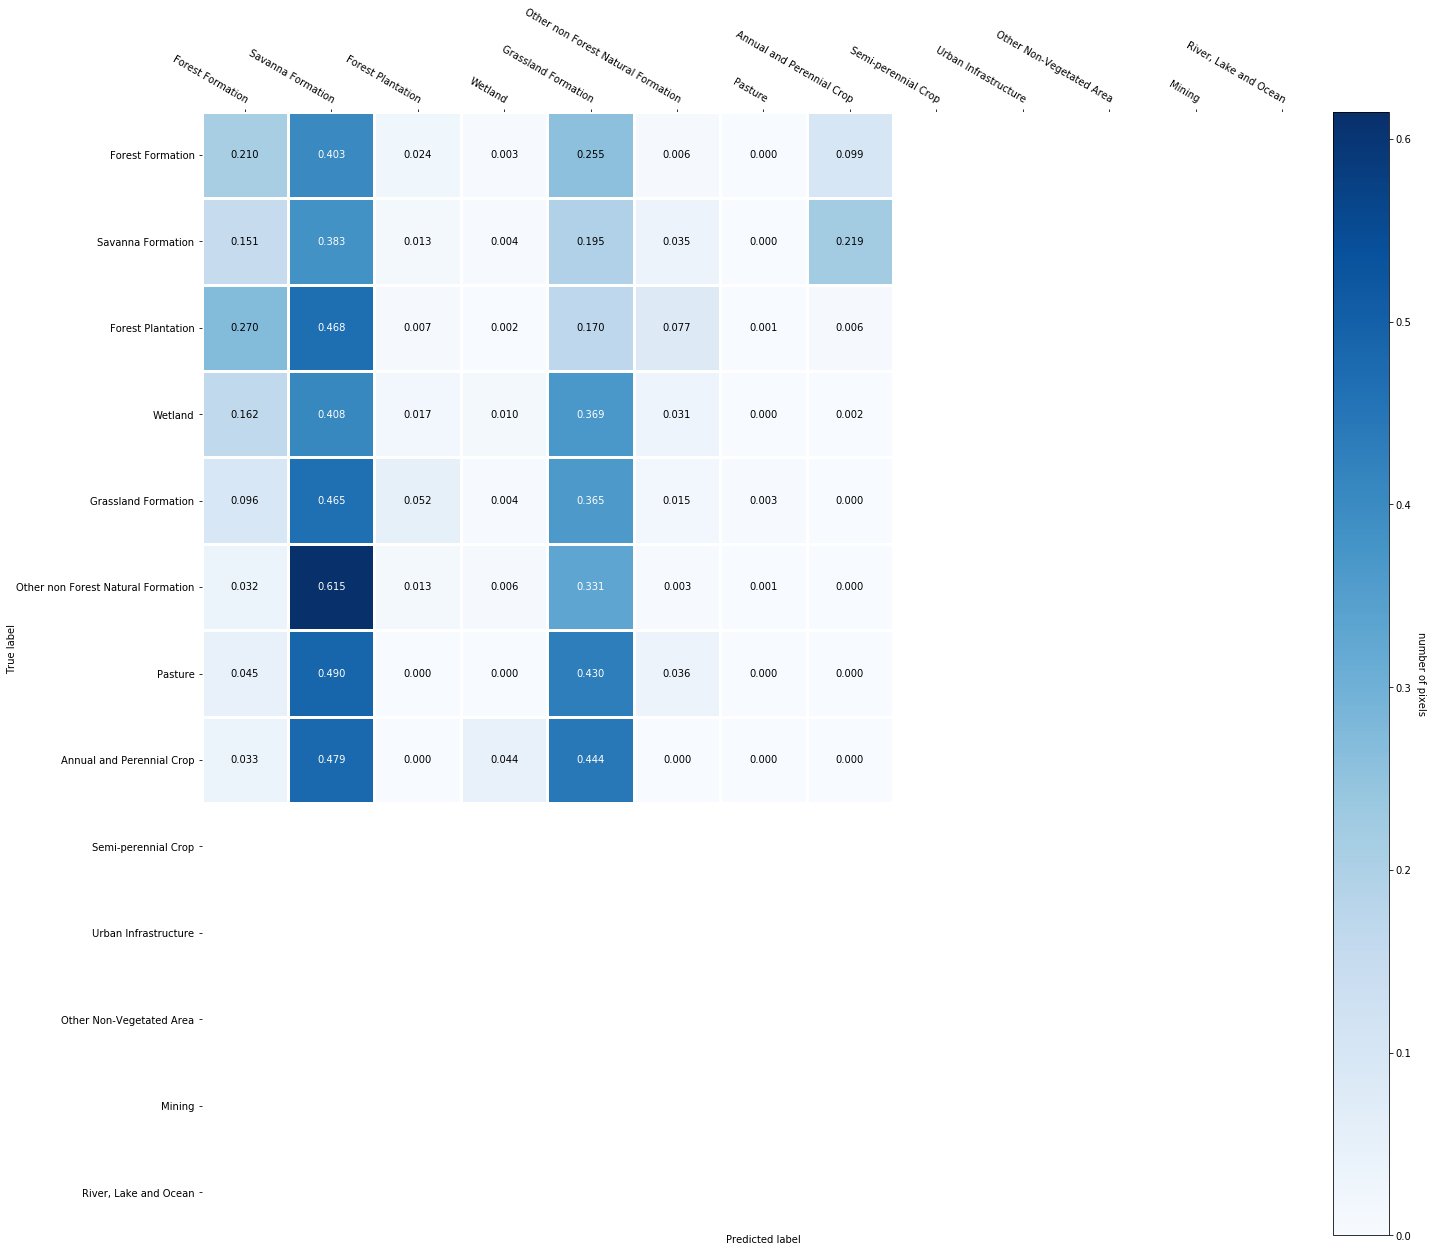

In [52]:
fig, ax = plt.subplots(figsize=(20,20))
#fig, ax = plt.subplots()

im, cbar = heatmap(cmTest, target_names,target_names, ax=ax,
                   cbarlabel="number of pixels")
texts = annotate_heatmap(im, valfmt="{x:.3f}")

fig.tight_layout()
plt.show()

In [ ]:
name_fig="TwoBTest_Nor_CM.png"
fig.savefig(name_fig)